# Part II: Non-Isotropic Scattering

For Part II, we replace isotropic scattering with the Henyey-Greenstein phase function:

$$
P_{HG}(\cos\Theta)
=
\frac{1-g^2}
{\left(1+g^2-2g\cos\Theta\right)^{3/2}}
$$



The cumulative distribution function from part I is:

$$
C(\cos\Theta)
=
\frac{1}{2}
\int_{-1}^{\cos\Theta}
P_{HG}(x)\,dx
$$

Substituting the Henyey-Greenstein phase function gives:

$$
C(\cos\Theta)
=
\frac{1}{2}
\int_{-1}^{\cos\Theta}
\frac{1-g^2}
{\left(1+g^2-2gx\right)^{3/2}}
\,dx
$$

Now we'll do a simple change of variable:

$$
u = 1 + g^2 - 2gx
$$

Then

$$
du = -2g\,dx
$$

so

$$
dx = -\frac{du}{2g}
$$

Then the integral changes to:

$$
C(\cos\Theta)
=
\frac{1}{2}
(1-g^2)
\int
u^{-3/2}
\left(-\frac{du}{2g}\right)
$$

$$
C(\cos\Theta)
=
-\frac{1-g^2}{4g}
\int u^{-3/2}\,du
$$


and we'll get:

$$
C(\cos\Theta)
=
\frac{1-g^2}{2g}
u^{-1/2}
$$

Now we change the variable back to the original form and apply the limits from \(x=-1\) to $x = \cos\Theta$:


$$
C(\cos\Theta)
=
\frac{1-g^2}{2g}
\left[
\frac{1}{\sqrt{1+g^2-2g\cos\Theta}}
-
\frac{1}{\sqrt{1+g^2+2g}}
\right]
$$


If we simplify the equation then we'll have:

$$
C(\cos\Theta)
=
\frac{1}{2g}
\left[
\frac{1-g^2}{\sqrt{1+g^2-2g\cos\Theta}}
-
(1-g)
\right]
$$

Now we set the cumulative probability equal to a random number:

$$
C(\cos\Theta) = \zeta
$$

where

$$
\zeta \sim U(0,1)
$$


$$
\zeta
=
\frac{1}{2g}
\left[
\frac{1-g^2}{\sqrt{1+g^2-2g\cos\Theta}}
-
(1-g)
\right]
$$


$$
2g\zeta
=
\frac{1-g^2}{\sqrt{1+g^2-2g\cos\Theta}}
-
(1-g)
$$


$$
1-g+2g\zeta
=
\frac{1-g^2}{\sqrt{1+g^2-2g\cos\Theta}}
$$


$$
\sqrt{1+g^2-2g\cos\Theta}
=
\frac{1-g^2}{1-g+2g\zeta}
$$


$$
1+g^2-2g\cos\Theta
=
\left(
\frac{1-g^2}{1-g+2g\zeta}
\right)^2
$$


$$
-2g\cos\Theta
=
\left(
\frac{1-g^2}{1-g+2g\zeta}
\right)^2
-
1
-
g^2
$$


$$
2g\cos\Theta
=
1+g^2
-
\left(
\frac{1-g^2}{1-g+2g\zeta}
\right)^2
$$

Finally,

$$
\cos\Theta
=
\frac{1}{2g}
\left[
1+g^2
-
\left(
\frac{1-g^2}{1-g+2g\zeta}
\right)^2
\right]
$$


So the final scattering angle is:

$$
\boxed{
\cos\Theta
=
\frac{1}{2g}
\left[
1+g^2
-
\left(
\frac{1-g^2}{1-g+2g\zeta}
\right)^2
\right]
}
$$


For the special case of:

$$
g = 0
$$

the Henyey-Greenstein phase function becomes isotropic similar to part I, and we'll have:

$$
\boxed{
\cos\Theta = 2\zeta - 1
}
$$

So the only the change to the coordinate rotation system is how we calculate $\cos\Theta$ for a non-isotropic scattering according to the equation above and also introducing g as anew argument to the function. I'll also add the isotropic scattering case as a logic for when g =0:

In [6]:
import numpy as np 
import matplotlib.pyplot as plt

#########Define the function to get the incoming photon direction, change it to photon coordinates, and change it back to the new photon direction
def coordinate_rotation_non_isotropic(k, g):


    # Incoming photon coordinate system
    zp = k 

    kx, ky, kz = zp

    # Define xp
    horizontal_norm = np.sqrt(kx**2 + ky**2)

    if horizontal_norm < 1e-10:  # For the special case when photon is nearly vertical
        xp = np.array([1.0, 0.0, 0.0])
    else:
        xp = np.array([-ky, kx, 0.0]) / horizontal_norm

    # Define yp
    yp = np.cross(zp, xp)

    # Draw non-isotropic scattering angles
    zeta = np.random.uniform(0, 1)

    if abs(g) < 1e-12:
        cos_theta = 2 * zeta - 1 #isotropic scattering
    else:
        cos_theta = (1 / (2 * g)) * (
            1 + g**2
            - ((1 - g**2) / (1 - g + 2 * g * zeta))**2 #non-isotropic scattering
        )
    # Numerical safety to make sure cos theta is in the valid range [-1, 1]
    cos_theta = np.clip(cos_theta, -1, 1)
    sin_theta = np.sqrt(1 - cos_theta**2)
    phi = 2 * np.pi * np.random.uniform(0,1)

    # Scattered direction in photon coordinates
    kp = np.array([
        sin_theta * np.cos(phi),
        sin_theta * np.sin(phi),
        cos_theta
    ])


    # Rotate back into model coordinates
    knew = kp[0] * xp + kp[1] * yp + kp[2] * zp

    return knew

Now, I'll define the core monte carlo model similar to what I had for part I. The only difference is going to be adding asymmetry parameter as a new argument to the model.

In [8]:
########Define the model 


def monte_carlo_scattering(N, tau_star, theta_deg, z_atm, omega, phi_deg, g, max_scatter=1000):
    
    theta0 = np.radians(theta_deg)
    phi0 = np.radians(phi_deg)

    if theta_deg >= 90:
        raise ValueError("Theta must be less than 90 degrees.")
    
    
    # Initial direction vector
    k0 = np.array([
        np.cos(phi0) * np.sin(theta0),
        np.sin(phi0) * np.sin(theta0),
        -np.cos(theta0)
    ])
    
    # Extinction coefficient for a homogeneous atmosphere
    beta_e = tau_star / z_atm
    
    # Arrays to store photons' traveled pathlengths
    final_pathlength = np.zeros(N)
    
    #stores how many times each photon scatters
    scatter_counts = np.zeros(N, dtype=int)
    
    #stores the final fate of each photon
    photon_fate = np.array(["survived"] * N, dtype=object)
    
    ###First pathlengths before an extinction event###
    
    zeta = np.random.uniform(0,1,N) #Here we assign a number between 0 and 1 (in this case absorption probability) to each photon
    
    #calculate the optical depth traveled by a photon before extinction 
    tau_traveled = -np.log(1-zeta)
    
    #calculate the physical pathlength traveled by each photon before extinction
    geometric_pathlength = (z_atm * tau_traveled) / (tau_star)
    
    #Distance to the surface in the initial direction
    distance_to_surface = z_atm / abs(k0[2])
    
    # Photons that reach surface before first extinction
    direct_surface_photons = geometric_pathlength >= distance_to_surface
    
    photon_fate[direct_surface_photons] = "direct_surface"
    
    final_pathlength[direct_surface_photons] = distance_to_surface
    
    # Photons that have extinction inside the atmosphere
    extinction = ~direct_surface_photons
    
    # Their first extinction height
    z_extinction = z_atm + geometric_pathlength * k0[2]

    # Store first path segment for extinct photons
    final_pathlength[extinction] = geometric_pathlength[extinction]
    
    
    ###Decision for scattering or absorption###
    
    #assign a random number to each photon and decide whether it is absorbed or scattered at the extinction event
    extinction_event = np.random.uniform(0, 1, N)
    absorbed = extinction & (extinction_event >= omega)
    scattered = extinction & (extinction_event < omega)
    
    photon_fate[absorbed] = "absorbed"
    
    ###Scattering loop###
    
    for i in np.where(scattered)[0]:
    
        #set the height of the photon to the extinction height
        z = z_extinction[i]
        #new direction after scattering transformed from the photon coordinates back to model coordinates
        k = coordinate_rotation_non_isotropic(k0, g)
        #add a scattering event to the scatter count for this photon
        scatter_counts[i] = 1
        #mark the photon as alive
        alive = True
        
        while alive:
            # draw random optical depth to next extinction event
            zeta_scatter = np.random.uniform(0, 1)
            tau_traveled_scatter = -np.log(1 - zeta_scatter)
            # convert optical depth to geometric pathlength along photon path
            geometric_pathlength_scatter = (z_atm * tau_traveled_scatter) / (tau_star)
            # compute distance to boundary using current position and direction
            if k[2] < 0:
                distance_to_boundary = z / abs(k[2])
                boundary = "surface"

            elif k[2] > 0:
                distance_to_boundary = (z_atm - z) / k[2]
                boundary = "top of atmosphere"
            else:
                distance_to_boundary = np.inf
                boundary = None
                
            #check to see if the photon reaches any of the boundaries before the next extinction event
            if geometric_pathlength_scatter >= distance_to_boundary: #in this case the photon reaches TOA or surface after scattering
                final_pathlength[i] += distance_to_boundary
                if boundary == 'surface':
                    photon_fate[i] = "diffuse_surface"
                elif boundary == 'top of atmosphere':
                    photon_fate[i] = "reflected"
                alive = False
            else: #in this case the photon has another extinction event before reaching any boundary
                final_pathlength[i] += geometric_pathlength_scatter
                # move photon to extinction location
                z = z + geometric_pathlength_scatter * k[2]
                # decide absorption or scattering
                if np.random.uniform(0, 1) < omega:
                    k = coordinate_rotation_non_isotropic(k, g)
                    scatter_counts[i] += 1
                    if scatter_counts[i] > max_scatter:
                        photon_fate[i] = "max_scatter_reached"
                        alive = False
                else:
                    photon_fate[i] = "absorbed"
                    alive = False


    N_direct_surface = np.sum(photon_fate == "direct_surface")
    N_diffuse_surface = np.sum(photon_fate == "diffuse_surface")
    N_reflected = np.sum(photon_fate == "reflected")
    N_absorbed_atm = np.sum(photon_fate == "absorbed")
    N_max_scatter = np.sum(photon_fate == "max_scatter_reached")
    
    results = {
        "N": N,
        "tau_star": tau_star,
        "theta_deg": theta_deg,
        "phi_deg": phi_deg,
        "mu0": np.abs(k0[2]),
        "omega": omega,
        "g": g,

        "N_direct_surface": N_direct_surface,
        "N_diffuse_surface": N_diffuse_surface,
        "N_reflected": N_reflected,
        "N_absorbed_atm": N_absorbed_atm,
        "N_max_scatter": N_max_scatter,

        "direct_transmittance": N_direct_surface / N,
        "diffuse_transmittance": N_diffuse_surface / N,
        "total_surface_transmittance": (N_direct_surface + N_diffuse_surface) / N,
        "albedo": N_reflected / N,
        "atmospheric_absorptance": N_absorbed_atm / N,

        "photons fate": photon_fate,
        "final_pathlength": final_pathlength,
        "Extinction heights": z_extinction,
        "scatter_counts": scatter_counts
    }
    
    
    return results

In [9]:
##### Helper to print a summary table of the results
import pandas as pd
def summary(results):
    summary_keys = [
        "N",
        "tau_star",
        "theta_deg",
        "phi_deg",
        "mu0",
        "omega",
        "g",
        "N_direct_surface",
        "N_diffuse_surface",
        "N_reflected",
        "N_absorbed_atm",
        "N_max_scatter",
        "direct_transmittance",
        "diffuse_transmittance",
        "total_surface_transmittance",
        "albedo",
        "atmospheric_absorptance",
        "photons fate",
        "final_pathlength",
        "Extinction heights",
        "scatter_counts"
    ]

    summary_table = pd.DataFrame({
        "quantity": summary_keys,
        "value": [results[key] for key in summary_keys]
    })

    return summary_table

# Validation 1

For the first test, I used a purely scattering atmosphere case with optical depth of 1 and solar zenith angle of 0 and asymmetry parameter of 0. In this case, the model should show zero atmospheric absorption and also close values to validation 2 of part I of homework, meaning an isotropic scattering.

In [30]:
results = monte_carlo_scattering(1000000, 1, 0, 8000, 1, 0, 0, max_scatter=1000)
summary_table = summary(results)
summary_table

,quantity,value
0,N,1000000
1,tau_star,1
2,theta_deg,0
3,phi_deg,0
4,mu0,1.0
5,omega,1
6,g,0
7,N_direct_surface,367488
8,N_diffuse_surface,290853
9,N_reflected,341659


# Validation 2

For the second test, I used a purely scattering atmosphere case with optical depth of 1 and solar zenith angle of 0 and asymmetry parameter of 1. In this case, the model should show zero albedo because all the scattering is in forward.

In [36]:
results = monte_carlo_scattering(1000000, 1, 0, 8000, 1, 0, 1, max_scatter=1000)
summary_table = summary(results)
summary_table

,quantity,value
0,N,1000000
1,tau_star,1
2,theta_deg,0
3,phi_deg,0
4,mu0,1.0
5,omega,1
6,g,1
7,N_direct_surface,367389
8,N_diffuse_surface,632611
9,N_reflected,0


# Question a


For this question, we want to show that for an optically thin atmosphere,

$$
\tau \ll 1
$$

and isotropic scattering,

$$
g = 0
$$

the albedo is approximately

$$
\alpha \approx \frac{\tau \tilde{\omega}}{2}
$$

when the solar zenith angle is

$$
\theta_0 = 0^\circ
$$

so that

$$
\mu_0 = \cos\theta_0 = 1
$$

The albedo is the fraction of incoming photons that are scattered upward and escape through the top of the atmosphere. For a photon traveling through optical depth $\tau$, the probability of no extinction is given by Beer's Law:

$$
P(\text{no extinction}) = e^{-\tau}
$$

Therefore, the probability that a photon experiences at least one extinction event is:

$$
P(\text{extinction}) = 1 - e^{-\tau}
$$

For an optically thin atmosphere, we can use the approximation:

$$
e^{-\tau} \approx 1 - \tau
$$

so

$$
P(\text{extinction})
\approx
1 - (1-\tau)
$$

which gives:

$$
P(\text{extinction}) \approx \tau
$$

Only a fraction $\tilde{\omega}$ of extinction events are scattering events. Therefore, the probability that a photon scatters is:

$$
P(\text{scattering})
\approx
\tau \tilde{\omega}
$$

For isotropic scattering, scattering is equally likely into all directions. Therefore, half of the scattered photons go into the upward hemisphere and half go into the downward hemisphere.Thus, the fraction of incoming photons that scatter upward is:

$$
P(\text{upward scattering})
\approx
\frac{1}{2}
P(\text{scattering})
$$

Substituting the scattering probability gives:

$$
P(\text{upward scattering})
\approx
\frac{1}{2}
\tau \tilde{\omega}
$$

Since the atmosphere is optically thin, most upward-scattered photons escape to space without another interaction. Therefore, the albedo is approximately equal to the upward-scattered fraction:

$$
\boxed{
\alpha \approx \frac{\tau \tilde{\omega}}{2}
}
$$


# Question b

Now I'll use the model to test the relationship between albedo, optical depth, and single scattering albedo for an optically thin atmosphere. For this purpose, I set the optical depth to 0.01, the single scattering albedo to 1, the asymmetry parameter to 0, and the zenith angle to 0. The results show that albedo is 0.00498 from the model simulation. If we use the optical depth and single scattering albedo values and plugged it into the theoretical relationship above, it would result in 0.005, which is pretty close to the model simulation result for albedo. 


In [37]:
results = monte_carlo_scattering(1000000, 0.01, 0, 8000, 1, 0, 0, max_scatter=1000)
summary_table = summary(results)
summary_table

,quantity,value
0,N,1000000
1,tau_star,0.01
2,theta_deg,0
3,phi_deg,0
4,mu0,1.0
5,omega,1
6,g,0
7,N_direct_surface,989966
8,N_diffuse_surface,5054
9,N_reflected,4980


# Question c

The quantity of interest is:

$$
f(g) = \frac{\alpha}{\tau \tilde{\omega}}
$$


For an optically thin atmosphere, most photons experience either zero or one scattering event. The probability of scattering is approximately

$$
P_{\text{scat}} \approx \tau \tilde{\omega}
$$

The albedo is the fraction of incoming photons that are scattered upward and escape through the top of the atmosphere. Therefore, albedo can be written approximately as:

$$
\alpha \approx \tau \tilde{\omega} f(g)
$$

where $\ f(g)$ represents the fraction of scattered photons directed into the backward or upward hemisphere.

For isotropic scattering:
$$
g = 0
$$

scattering is equally likely in all directions. Therefore, approximately half of the scattered photons are directed upward and half downward, which we showed in the previous question:

$$
f(0) \approx \frac{1}{2}
$$

As g increases, the Henyey-Greenstein phase function becomes more forward scattering. Therefore, the albedo decreases as g increases. In addition, as g decreases to negative values, backscatter becomes stronger and thus the albedo increases.

The Monte Carlo results in the table and figure below show that $\ f(g)$ and albedo decreases with increasing g. This means that, for fixed optical depth and single scatter albedo, the atmosphere reflects less radiation back to space when scattering is more forward-directed. The results also show that as g decreases, the $\ f(g)$ and albedo increases, meaning more backscatter into the space happens.


In [47]:
g_values = np.linspace(-1, 1, 20)
rows = []
for g in g_values:
    results = monte_carlo_scattering(1000000, 0.01, 0, 8000, 0.5, 0, g, max_scatter=1000)
    rows.append({
        "g": g,
        "albedo": results["albedo"],
        "diffuse_transmittance": results["diffuse_transmittance"],
        "f_g": results["albedo"] / (0.01 * 0.5)
    })

g_df = pd.DataFrame(rows)
g_df

,g,albedo,diffuse_transmittance,f_g
0,-1.000000,0.004933,0.000011,0.9866
1,-0.894737,0.004902,0.000139,0.9804
2,-0.789474,0.004756,0.000263,0.9512
3,-0.684211,0.004472,0.000426,0.8944
4,-0.578947,0.004403,0.000655,0.8806
5,-0.473684,0.003974,0.000903,0.7948
6,-0.368421,0.003667,0.001199,0.7334
7,-0.263158,0.003339,0.001519,0.6678
8,-0.157895,0.002954,0.001958,0.5908
9,-0.052632,0.002635,0.002211,0.5270


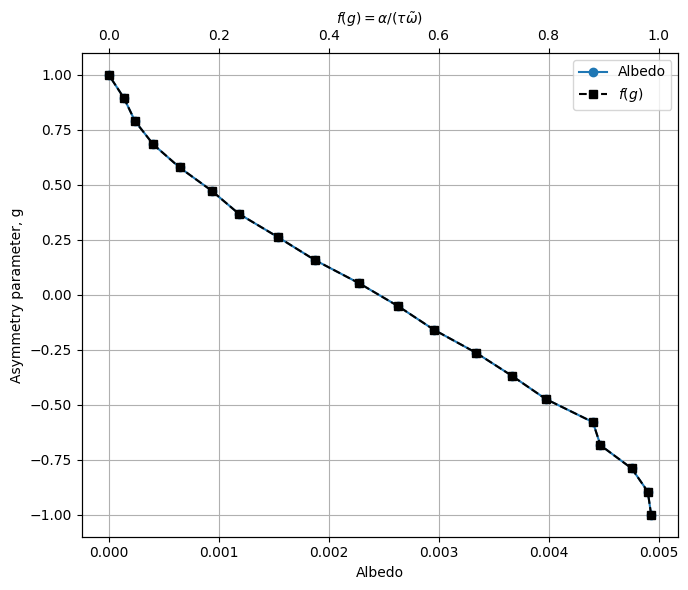

In [48]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(7, 6))

# Bottom x-axis: albedo
ax1.plot(
    g_df["albedo"],
    g_df["g"],
    marker="o",
    label="Albedo"
)

ax1.set_xlabel("Albedo")
ax1.set_ylabel("Asymmetry parameter, g")
ax1.grid(True)

# Top x-axis: f(g)
ax2 = ax1.twiny()

ax2.plot(
    g_df["f_g"],
    g_df["g"],
    marker="s",
    linestyle="--",
    color="black",
    label=r"$f(g)$"
)

ax2.set_xlabel(r"$f(g) = \alpha / (\tau \tilde{\omega})$")

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best"
)

plt.tight_layout()
plt.show()

# Question d


The backscatter function, $\ B(g)$, is the fraction of scattered light directed into the backward hemisphere:

$$
B(g)
=
\frac{1}{2}
\int_{-1}^{0}
P_{HG}(\mu,g)\,d\mu
$$

where

$$
\mu = \cos\Theta
$$

and the Henyey-Greenstein phase function is:

$$
P_{HG}(\mu,g)
=
\frac{1-g^2}
{\left(1+g^2-2g\mu\right)^{3/2}}
$$

Therefore:

$$
B(g)
=
\frac{1}{2}
\int_{-1}^{0}
\frac{1-g^2}
{\left(1+g^2-2g\mu\right)^{3/2}}
\,d\mu
$$

Similar to the first section of this homework, we can solve this integral and the final result will be:


$$
\boxed{
B(g)
=
\frac{1}{2g}
\left[
\frac{1-g^2}{\sqrt{1+g^2}}
-
(1-g)
\right]
}
$$

For the special case g=0, the Henyey-Greenstein phase function reduces to isotropic scattering. Therefore, half of the scattered photons go into the backward hemisphere:

$$
\boxed{
B(0)=\frac{1}{2}
}
$$

In the Monte Carlo model, for an optically thin atmosphere and overhead sun,

$$
\tau \ll 1
$$

and

$$
\mu_0 = 1
$$

the scattering probability is approximately

$$
\tau \tilde{\omega}
$$

The albedo is the fraction of photons that scatter into the backward hemisphere and escape to space. Therefore,

$$
\alpha \approx \tau \tilde{\omega} B(g)
$$

so

$$
f(g)
=
\frac{\alpha}{\tau \tilde{\omega}}
\approx
B(g)
$$

The Monte Carlo results should therefore match the analytical backscatter function $\ B(g)$ in the optically thin limit. As shown in the table and figure below, in the case of an optically thin atmosphere, the $\ f(g)$ and $\ B(g)$ functions show close values when varying the asymmetry parameter.

In [53]:
#########Calculate the analytical backscatter fraction for the Henyey-Greenstein phase function 
def B_analytical(g):

    g = np.asarray(g)

    B = np.empty_like(g, dtype=float)

    near_zero = np.abs(g) < 1e-12

    B[near_zero] = 0.5

    B[~near_zero] = (1 / (2 * g[~near_zero])) * (
        (1 - g[~near_zero]**2) / np.sqrt(1 + g[~near_zero]**2)
        - (1 - g[~near_zero])
    )

    return B

###########Run model
g_values = np.linspace(-1, 1, 20)

tau_star = 0.01
omega = 0.5
N = 1000000

rows = []

for g in g_values:
    results = monte_carlo_scattering(
        N=N,
        tau_star=tau_star,
        theta_deg=0,
        z_atm=8000,
        omega=omega,
        phi_deg=0,
        g=g,
        max_scatter=1000
    )

    f_g = results["albedo"] / (tau_star * omega)

    rows.append({
        "g": g,
        "albedo": results["albedo"],
        "diffuse_transmittance": results["diffuse_transmittance"],
        "f_g_model": f_g,
        "B_g_analytical": B_analytical(np.array([g]))[0]
    })

g_df = pd.DataFrame(rows)

g_df

,g,albedo,diffuse_transmittance,f_g_model,B_g_analytical
0,-1.000000,0.005015,0.000011,1.0030,1.000000
1,-0.894737,0.004831,0.000122,0.9662,0.975763
2,-0.789474,0.004757,0.000266,0.9514,0.946063
3,-0.684211,0.004521,0.000468,0.9042,0.910002
4,-0.578947,0.004275,0.000707,0.8550,0.866741
5,-0.473684,0.004010,0.000972,0.8020,0.815653
6,-0.368421,0.003758,0.001188,0.7516,0.756530
7,-0.263158,0.003339,0.001510,0.6678,0.689805
8,-0.157895,0.003099,0.001837,0.6198,0.616732
9,-0.052632,0.002543,0.002257,0.5086,0.539410


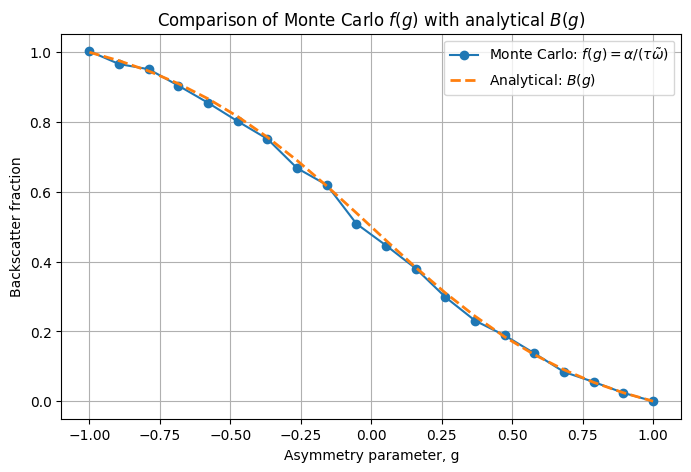

In [54]:
plt.figure(figsize=(8, 5))

plt.plot(
    g_df["g"],
    g_df["f_g_model"],
    marker="o",
    label=r"Monte Carlo: $f(g)=\alpha/(\tau\tilde{\omega})$"
)

plt.plot(
    g_df["g"],
    g_df["B_g_analytical"],
    linestyle="--",
    linewidth=2,
    label=r"Analytical: $B(g)$"
)

plt.xlabel("Asymmetry parameter, g")
plt.ylabel("Backscatter fraction")
plt.title(r"Comparison of Monte Carlo $f(g)$ with analytical $B(g)$")
plt.grid(True)
plt.legend()
plt.show()

# Question e

We have shown in questions a through d that for an optically thin atmosphere for isotropic scattering the albedo is half of the product of single scattering albedo and optical depth and in case of a non-isotropic scattering, we defined $\ f(g)$ which represents a simple form of the backscattering analytical function. Now I want to see what is the optical thickness limit of the atmosphere where these simplifications do not hold anymore.
For very small optical depth, the Monte Carlo albedo should agree with the analytical approximation:

$$
\alpha_{\text{thin}} = \tau \tilde{\omega} B(g)
$$

because multiple scattering is unlikely. As optical depth increases, photons become more likely to experience multiple scattering events before either escaping to space, reaching the surface, or being absorbed. Therefore, the single-scattering approximation should break down. As shown below for an isotropic scattering, starting from optical depths around 0.1, the theoretical albedo starts to diverge from the model. As we go pass optical depth of 0.3, the divergence is more clear and the theoretical albedo starts overestimating. As a result, the optically thin albedo approximation is valid for optical depths up to 0.2.

In [56]:
tau_values = np.logspace(-3, 0, 15)  # 0.001 to 1
omega = 1.0
g = 0
rows = []

for tau_star in tau_values:
    results = monte_carlo_scattering(
            N=1000000,
            tau_star=tau_star,
            theta_deg=0,
            z_atm=8000,
            omega=omega,
            phi_deg=0,
            g=g,
            max_scatter=1000
    )

    albedo_model = results["albedo"]
    albedo_theory = (tau_star * omega) / 2

    

    rows.append({
        "g": g,
        "tau_star": tau_star,
        "albedo_model": albedo_model,
        "albedo_theory": albedo_theory,
    })

hypothesis1_df = pd.DataFrame(rows)
hypothesis1_df

,g,tau_star,albedo_model,albedo_theory
0,0,0.001000,0.000503,0.000500
1,0,0.001638,0.000802,0.000819
2,0,0.002683,0.001326,0.001341
3,0,0.004394,0.002164,0.002197
4,0,0.007197,0.003596,0.003598
5,0,0.011788,0.005945,0.005894
6,0,0.019307,0.009515,0.009653
7,0,0.031623,0.015354,0.015811
8,0,0.051795,0.025013,0.025897
9,0,0.084834,0.040906,0.042417


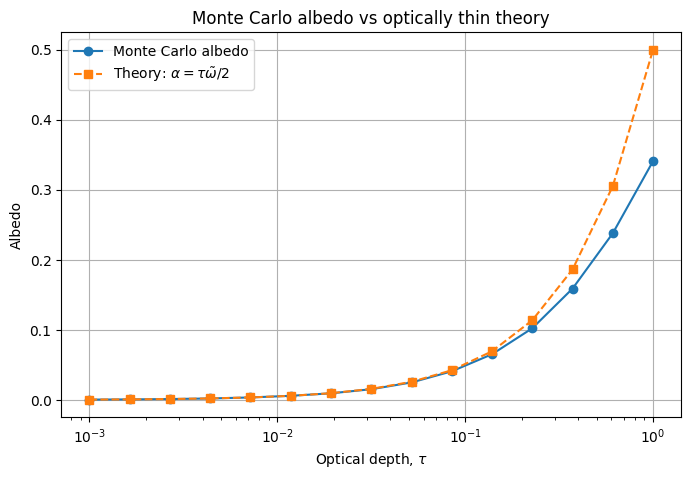

In [57]:
plt.figure(figsize=(8, 5))

plt.plot(
    hypothesis1_df["tau_star"],
    hypothesis1_df["albedo_model"],
    marker="o",
    label="Monte Carlo albedo"
)

plt.plot(
    hypothesis1_df["tau_star"],
    hypothesis1_df["albedo_theory"],
    marker="s",
    linestyle="--",
    label=r"Theory: $\alpha = \tau \tilde{\omega}/2$"
)

plt.xscale("log")
plt.xlabel(r"Optical depth, $\tau$")
plt.ylabel("Albedo")
plt.title("Monte Carlo albedo vs optically thin theory")
plt.grid(True)
plt.legend()
plt.show()

The Monte Carlo results show that the optically thin approximation works best at small optical depth. In this limit, the normalized albedo function:

$$
f(g) = \frac{\alpha}{\tau \tilde{\omega}}
$$

is close to the analytical backscatter function:

$$
B(g).
$$

This agreement occurs because most photons experience at most one scattering event, so the albedo is controlled mainly by the probability of scattering and the fraction of scattered photons directed into the backward hemisphere. As optical depth increases, the Monte Carlo results deviate from the analytical \(B(g)\). This indicates that the single-scattering approximation no longer holds. At larger optical depth, photons can undergo multiple scattering events, be absorbed, or escape through either boundary. Therefore, the simple relationship:

$$
\alpha \approx \tau \tilde{\omega} B(g)
$$

breaks down.

The breakdown is most visible for the negative g cases, where backscattering is strong. At larger optical depth, photons that are initially backscattered may scatter again before escaping, so their final fate is no longer determined only by the first scattering event. This causes the Monte Carlo $\ f(g)$ to move away from the analytical backscatter fraction. For the case of stronger backscattering, the $\ f(g)$ function starts to deviate from the analytical backscatter function at around 0.1 optical depth.

In [62]:
tau_values = np.logspace(-3, 0, 15)  # 0.001 to 1
g_values = [-0.5, -0.2, 0.5, 0.8]
omega = 1.0

rows = []

for g in g_values:
    B_g = B_analytical(np.array([g]))[0]

    for tau_star in tau_values:
        results = monte_carlo_scattering(
            N=100000,
            tau_star=tau_star,
            theta_deg=0,
            z_atm=8000,
            omega=omega,
            phi_deg=0,
            g=g,
            max_scatter=1000
        )

        f_g = results["albedo"] / (tau_star * omega)

        rows.append({
            "g": g,
            "tau_star": tau_star,
            "albedo_model": results["albedo"],
            "f_g": f_g,
            "B_g": B_g,
        })

hypothesis2_df = pd.DataFrame(rows)
hypothesis2_df

,g,tau_star,albedo_model,f_g,B_g
0,-0.5,0.001000,0.00090,0.900000,0.829180
1,-0.5,0.001638,0.00117,0.714332,0.829180
2,-0.5,0.002683,0.00196,0.730608,0.829180
3,-0.5,0.004394,0.00346,0.787443,0.829180
4,-0.5,0.007197,0.00602,0.836476,0.829180
5,-0.5,0.011788,0.00958,0.812712,0.829180
6,-0.5,0.019307,0.01531,0.792978,0.829180
7,-0.5,0.031623,0.02470,0.781083,0.829180
8,-0.5,0.051795,0.04119,0.795254,0.829180
9,-0.5,0.084834,0.06540,0.770915,0.829180


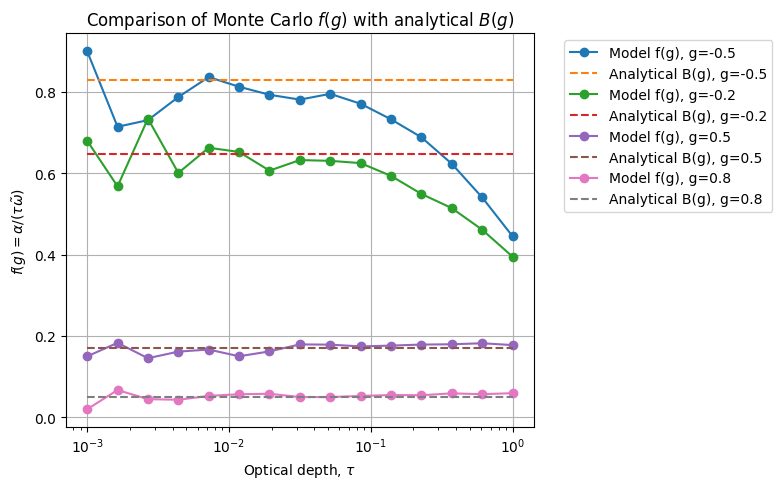

In [63]:
plt.figure(figsize=(8, 5))

for g in g_values:
    subset = hypothesis2_df[hypothesis2_df["g"] == g]

    plt.plot(
        subset["tau_star"],
        subset["f_g"],
        marker="o",
        label=f"Model f(g), g={g}"
    )

    plt.plot(
        subset["tau_star"],
        subset["B_g"],
        linestyle="--",
        label=f"Analytical B(g), g={g}"
    )

plt.xscale("log")
plt.xlabel(r"Optical depth, $\tau$")
plt.ylabel(r"$f(g) = \alpha / (\tau \tilde{\omega})$")
plt.title(r"Comparison of Monte Carlo $f(g)$ with analytical $B(g)$")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# AI Usage

Tool: ChatGPT

Usage:

1. I used AI for all the plotting and figures in this homework.
2. AI was used to create the summary table for the results of the model.
3. AI was used to clean up the markdown text and write all the equations in the correct format.